In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

In [2]:
df = pd.read_csv('PJME_hourly.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.9 MB


In [4]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


In [6]:
df.head(10)

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
5,2002-12-31 06:00:00,26222.0
6,2002-12-31 07:00:00,28702.0
7,2002-12-31 08:00:00,30698.0
8,2002-12-31 09:00:00,31800.0
9,2002-12-31 10:00:00,32359.0


In [7]:
def calculate_price(row):
    hour = row.hour
    if 8 <= hour < 21:        # day
        return 5.0
    return 1.5        # night

In [8]:
df['Price'] = df['Datetime'].dt.hour.apply(lambda h: calculate_price(pd.Timestamp(2024, 1, 1, h)))

In [9]:
df.head(10)

,Datetime,PJME_MW,Price
0,2002-12-31 01:00:00,26498.0,1.5
1,2002-12-31 02:00:00,25147.0,1.5
2,2002-12-31 03:00:00,24574.0,1.5
3,2002-12-31 04:00:00,24393.0,1.5
4,2002-12-31 05:00:00,24860.0,1.5
5,2002-12-31 06:00:00,26222.0,1.5
6,2002-12-31 07:00:00,28702.0,1.5
7,2002-12-31 08:00:00,30698.0,5.0
8,2002-12-31 09:00:00,31800.0,5.0
9,2002-12-31 10:00:00,32359.0,5.0


In [10]:
df['Hour'] = df['Datetime'].dt.hour
typical_day = df.groupby('Hour')[['PJME_MW', 'Price']].mean().reset_index()

base_load = typical_day['PJME_MW'].values
prices = typical_day['Price'].values
hours = typical_day['Hour'].values

In [11]:
heuristic_load = base_load.copy()
peak_hours = prices == 5.0
cheap_hours = prices == 1.5

shifted_energy = np.sum(base_load[peak_hours] * 0.1)
heuristic_load[peak_hours] *= 0.9
heuristic_load[cheap_hours] += shifted_energy / np.sum(cheap_hours)

In [12]:
def objective_normalized(load, prices, base_load, penalty_factor=50000):
    cost = np.sum(load * prices)
    
    deviation_pct = (load - base_load) / base_load
    penalty = penalty_factor * np.sum(deviation_pct**2)
    
    return cost + penalty

In [13]:
def energy_conservation(load, base_load):
    return np.sum(load) - np.sum(base_load)

In [14]:
x0 = base_load.copy()

In [22]:
constraints = {'type': 'eq', 'fun': energy_conservation, 'args': (base_load,)}
bounds = [(load * 0.2, load * 1.3) for load in base_load]

result = minimize(
    objective_normalized, 
    x0, 
    args=(prices, base_load), 
    method='SLSQP',
    bounds=bounds, 
    constraints=constraints,
    options={'maxiter': 1000, 'disp': False}
)

optimized_load = result.x

In [23]:
base_cost = np.sum(base_load * prices)
heur_cost = np.sum(heuristic_load * prices)
opt_cost = np.sum(optimized_load * prices)

print(f"Базові витрати: ${base_cost:,.2f}")
print(f"Витрати (Евристика): ${heur_cost:,.2f} (Економія: {100 - heur_cost/base_cost*100:.2f}%)")
print(f"Витрати (Оптимізація): ${opt_cost:,.2f} (Економія: {100 - opt_cost/base_cost*100:.2f}%)")

Базові витрати: $2,732,078.82
Витрати (Евристика): $2,574,355.85 (Економія: 5.77%)
Витрати (Оптимізація): $2,396,853.39 (Економія: 12.27%)


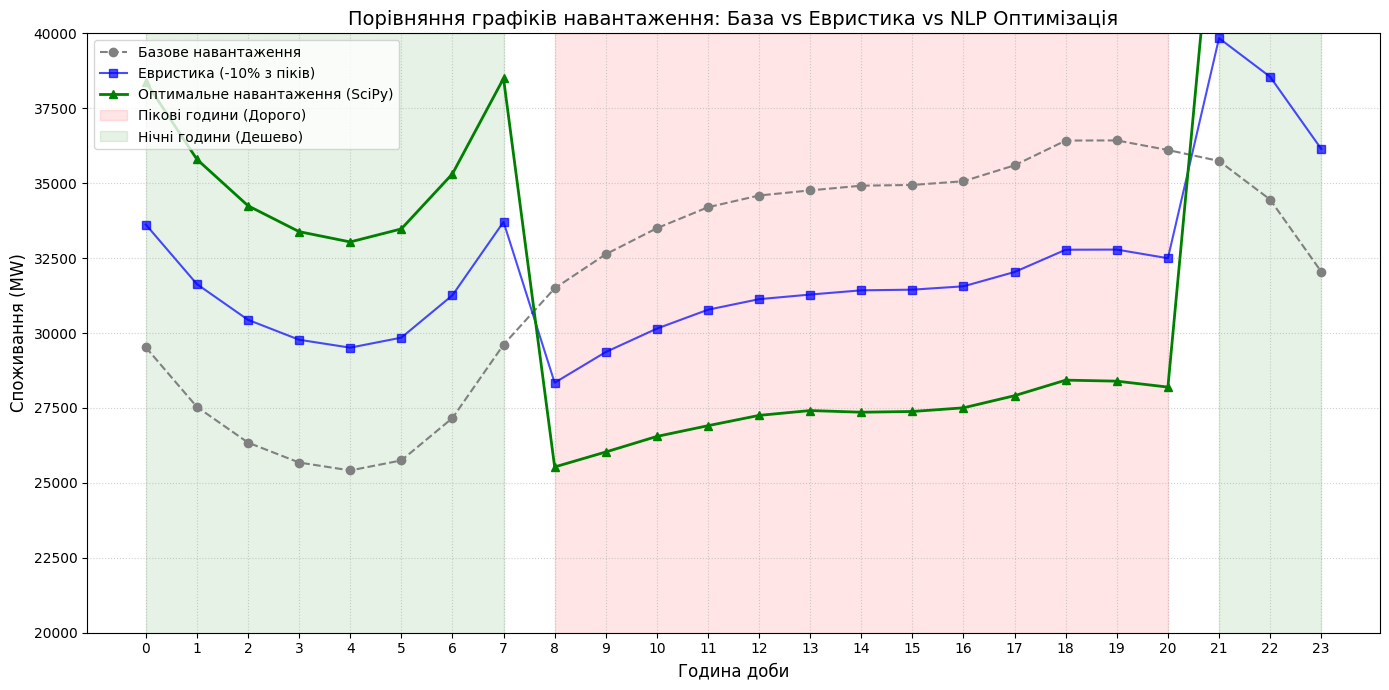

In [24]:
plt.figure(figsize=(14, 7))

plt.plot(hours, base_load, label='Базове навантаження', marker='o', linestyle='--', color='gray')
plt.plot(hours, heuristic_load, label='Евристика (-10% з піків)', marker='s', alpha=0.7, color='blue')
plt.plot(hours, optimized_load, label='Оптимальне навантаження (SciPy)', marker='^', linewidth=2, color='green')

plt.fill_between(hours, 0, 40000, where=(prices == 5.0), color='red', alpha=0.1, label='Пікові години (Дорого)')
plt.fill_between(hours, 0, 40000, where=(prices == 1.5), color='green', alpha=0.1, label='Нічні години (Дешево)')

plt.title('Порівняння графіків навантаження: База vs Евристика vs NLP Оптимізація', fontsize=14)
plt.xlabel('Година доби', fontsize=12)
plt.ylabel('Споживання (MW)', fontsize=12)
plt.xticks(hours)
plt.ylim(20000, 40000)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()